# Tokenization

**Tokenization** is the very first step in any NLP pipeline.
Before a model can read text, the text must be broken into small pieces called **tokens**.

A token can be:
- a **word** → `["I", "love", "NLP"]`
- a **subword** → `["un", "believ", "able"]`
- a **character** → `["I", " ", "l", "o", "v", "e"]`

In this notebook we will learn:
1. **Word tokenization** — the simplest approach and its problem
2. **Sentence tokenization** — splitting paragraphs into sentences
3. **Why word tokenization breaks** — the out-of-vocabulary (OOV) problem
4. **Byte Pair Encoding (BPE)** — how modern tokenizers work, traced step by step
5. **tiktoken** — the actual tokenizer used by GPT models

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

## 1. Word tokenization

The simplest approach: split on **whitespace** using Python's `.split()`.

In [ ]:
text = "I can't believe how useful NLP is — it's changing everything!"

tokens_split = text.split()

print("Original text:")
print(" ", text)
print()
print(f"Tokens ({len(tokens_split)}):")
print(" ", tokens_split)

Original text:
  I can't believe how useful NLP is — it's changing everything!

Tokens (11):
  ['I', "can't", 'believe', 'how', 'useful', 'NLP', 'is', '—', "it's", 'changing', 'everything!']


### Problem: punctuation sticks to words

Notice:
- `"can't"` stays as one token → the model won't understand it as `can` + `not`
- `"NLP"` and `"NLP,"` would be treated as **different** tokens
- The dash `—` and exclamation mark `!` are attached to words

`nltk.word_tokenize()` is smarter — it handles punctuation and contractions correctly.

In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

tokens_nltk = word_tokenize(text)

print("Original text:")
print(" ", text)
print()
print(f"NLTK tokens ({len(tokens_nltk)}):")
print(" ", tokens_nltk)
print()
print("What changed:")
print("  can't  ->  ['ca', """"n't""""]")  # split into can + n't
print("  it's   ->  ['it', """"'s""""]")    # split into it + 's
print("  !      ->  separate token")       # punctuation separated

Original text:
  I can't believe how useful NLP is — it's changing everything!

NLTK tokens (14):
  ['I', 'ca', "n't", 'believe', 'how', 'useful', 'NLP', 'is', '—', 'it', "'s", 'changing', 'everything', '!']

What changed:
  can't  ->  ['ca', n't]
  it's   ->  ['it', 's]
  !      ->  separate token


## 2. Sentence tokenization

Sometimes we first need to split a document into **sentences**, then tokenize each one.

`nltk.sent_tokenize()` is smart enough to know that a period inside `Dr.` or `9 a.m.`
does **not** end a sentence.

In [ ]:
from nltk.tokenize import sent_tokenize

paragraph = (
    "Dr. Ahmed is an NLP researcher at ITI. "
    "He published a paper on transformer models at 9 a.m. this morning. "
    "The paper shows that large language models can understand context remarkably well. "
    "His next lecture starts at 10 a.m. in room B2."
)

sentences = sent_tokenize(paragraph)

print(f"Paragraph has {len(sentences)} sentences:\n")
for i, sent in enumerate(sentences, 1):
    print(f"  [{i}] {sent}")

Paragraph has 4 sentences:

  [1] Dr. Ahmed is an NLP researcher at ITI.
  [2] He published a paper on transformer models at 9 a.m. this morning.
  [3] The paper shows that large language models can understand context remarkably well.
  [4] His next lecture starts at 10 a.m. in room B2.


> `Dr.` and `9 a.m.` and `10 a.m.` did **not** trigger a sentence split — NLTK recognized them as abbreviations, not sentence endings.

## 3. The out-of-vocabulary (OOV) problem

Word tokenization has a fundamental weakness: **the model only knows words it has seen during training**.

If a new word appears — a technical term, a brand name, a typo — the model has no representation for it.
This is called the **OOV (out-of-vocabulary) problem**.

| Strategy | Vocabulary size | OOV problem? | Handles new words? |
| --- | --- | --- | --- |
| Word | Very large (~100k+) | Yes, always | No |
| Character | Tiny (~100 chars) | No | Yes, but sequences are very long |
| **Subword (BPE)** | Medium (~30k–100k) | Rarely | Yes — splits into known pieces |

**Subword tokenization** is the solution used by every modern LLM (GPT, BERT, LLaMA, Gemini).
New words are split into smaller known subword units.

In [ ]:
# Example: what happens to rare / technical words?
example_words = [
    "hello",            # common word
    "transformer",      # technical but known
    "tokenization",     # technical
    "ChatGPT",          # brand name
    "backpropagation",  # long technical word
    "unbelievable",     # long but common
    "covid19",          # new word (pandemic era)
    "😊",               # emoji
]

print("Word tokenizer treats every word as ONE token — no matter how rare:")
for w in example_words:
    print(f"  {w}")
print()
print("If 'covid19' or '😊' is not in the vocabulary → OOV token (often <UNK>)")

Word tokenizer treats every word as ONE token — no matter how rare:
  hello
  transformer
  tokenization
  ChatGPT
  backpropagation
  unbelievable
  covid19
  😊

If 'covid19' or '😊' is not in the vocabulary → OOV token (often <UNK>)


## 4. Byte Pair Encoding (BPE) — step by step

BPE starts with **individual characters** and repeatedly merges the most frequent pair.

**The algorithm:**
1. Represent every word in the corpus as a sequence of characters (plus a special end-of-word marker `</w>`)
2. Count every pair of adjacent tokens across the corpus
3. Merge the **most frequent pair** into a single new token
4. Repeat until the vocabulary reaches the desired size

Let's trace this on a small corpus of 5 words.

### Step 1 — Start with characters

In [ ]:
# Our mini corpus: 5 words, some repeated to reflect frequency
# </w> marks the end of a word (helps the tokenizer know where words end)
raw_words = [
    "low",    # appears 5 times
    "low",
    "low",
    "low",
    "low",
    "newer",  # appears 6 times
    "newer",
    "newer",
    "newer",
    "newer",
    "newer",
    "wider",  # appears 3 times
    "wider",
    "wider",
    "lowest", # appears 2 times
    "lowest",
    "newest", # appears 2 times
    "newest",
]

# Split each word into characters and add </w> at the end
corpus = [list(word) + ["</w>"] for word in raw_words]

print("Initial character-level tokens (unique words):")
print()
seen = set()
for word in corpus:
    key = tuple(word)
    if key not in seen:
        seen.add(key)
        print(f"  {''.join(word[:-1]): <10}  →  {' | '.join(word)}")

Initial character-level tokens (unique words):

  low         →  l | o | w | </w>
  newer       →  n | e | w | e | r | </w>
  wider       →  w | i | d | e | r | </w>
  lowest      →  l | o | w | e | s | t | </w>
  newest      →  n | e | w | e | s | t | </w>


### Step 2 — Count adjacent pairs

We look at every pair of adjacent tokens across all words and count how often each pair appears.

In [ ]:
def count_pairs(corpus):
    """Count all adjacent token pairs across the corpus."""
    pairs = Counter()
    for word in corpus:
        for i in range(len(word) - 1):
            pairs[(word[i], word[i + 1])] += 1
    return pairs

# Show the top-10 most frequent pairs before any merges
pairs = count_pairs(corpus)
top_pairs = pairs.most_common(10)

print("Top 10 most frequent pairs (before any merges):")
print()
print(f"  {'Pair':<20} {'Count'}")
print("  " + "-" * 30)
for (a, b), count in top_pairs:
    print(f"  {repr(a)+' + '+repr(b):<20} {count}")

Top 10 most frequent pairs (before any merges):

  Pair                 Count
  ------------------------------
  's' + 't'            4
  't' + '</w>'         4
  'w' + 'i'            3
  'i' + 'd'            3
  'd' + 'e'            3
  'e' + 'r</w>'        3
  'lo' + 'we'          2
  'we' + 's'           2
  'newe' + 's'         2


### Step 3 — Merge the best pair, repeat

Each iteration:
- Find the most frequent pair
- Merge it everywhere in the corpus
- The merged pair becomes a single new token

We will run **8 merge steps** and watch the vocabulary grow.

In [ ]:
def merge_pair(corpus, pair):
    """Replace every occurrence of 'pair' with a single merged token."""
    merged_token = "".join(pair)
    new_corpus = []
    for word in corpus:
        new_word = []
        i = 0
        while i < len(word):
            # If current + next match the target pair, merge them
            if i < len(word) - 1 and (word[i], word[i + 1]) == pair:
                new_word.append(merged_token)  # one merged token
                i += 2                          # skip both originals
            else:
                new_word.append(word[i])
                i += 1
        new_corpus.append(new_word)
    return new_corpus


NUM_MERGES = 8
merges_log = []  # keep a record of every merge

print(f"{'Step':<6} {'Pair merged':<24} {'Freq':<8} {'New token':<14} Corpus state (unique words)")
print("-" * 90)

for step in range(NUM_MERGES):
    pairs = count_pairs(corpus)
    if not pairs:
        break
    best_pair = max(pairs, key=pairs.get)
    freq = pairs[best_pair]
    new_token = "".join(best_pair)
    merges_log.append((best_pair, new_token))

    # Show unique words AFTER this merge
    corpus = merge_pair(corpus, best_pair)
    unique = sorted({tuple(w) for w in corpus}, key=lambda w: len(w))
    state_str = "  |  ".join(" ".join(w) for w in unique)

    pair_str = repr(best_pair[0]) + " + " + repr(best_pair[1])
    print(f"{step+1:<6} {pair_str:<24} {freq:<8} {new_token:<14} {state_str}")

Step   Pair merged              Freq     New token      Corpus state (unique words)
------------------------------------------------------------------------------------------
1      'w' + 'e'                10       we             l o w </w>  |  n e we r </w>  |  w i d e r </w>  |  n e we s t </w>  |  l o we s t </w>
2      'r' + '</w>'             9        r</w>          l o w </w>  |  n e we r</w>  |  w i d e r</w>  |  n e we s t </w>  |  l o we s t </w>
3      'n' + 'e'                8        ne             ne we r</w>  |  l o w </w>  |  ne we s t </w>  |  w i d e r</w>  |  l o we s t </w>
4      'ne' + 'we'              8        newe           newe r</w>  |  l o w </w>  |  newe s t </w>  |  w i d e r</w>  |  l o we s t </w>
5      'l' + 'o'                7        lo             newe r</w>  |  lo w </w>  |  newe s t </w>  |  lo we s t </w>  |  w i d e r</w>
6      'newe' + 'r</w>'         6        newer</w>      newer</w>  |  lo w </w>  |  newe s t </w>  |  lo we s t </w>  |  w i 

**What to notice:**
- Early merges combine the most common character pairs (`e + r` → `er`, `n + e` → `ne`)
- After a few steps, common word-endings like `er</w>` become single tokens
- Eventually, entire common words like `low</w>` merge into one token
- Rare words are still split into smaller pieces — but those pieces are shared with other words

This is the key insight: **subword tokens are reusable across many words**.

### Visualize the final tokenization

In [ ]:
# Show how each word in the corpus is now tokenized
print("Final tokenization of each unique word:\n")
seen = set()
for word_tokens in corpus:
    key = tuple(word_tokens)
    if key not in seen:
        seen.add(key)
        original = "".join(t.replace("</w>", "") for t in word_tokens)
        token_str = "  |  ".join(word_tokens)
        print(f"  {original:<12}  →  [{token_str}]")

Final tokenization of each unique word:

  low           →  [low</w>]
  newer         →  [newer</w>]
  wider         →  [w  |  i  |  d  |  e  |  r</w>]
  lowest        →  [lo  |  we  |  s  |  t  |  </w>]
  newest        →  [newe  |  s  |  t  |  </w>]


## 5. BPE in practice — tiktoken (GPT's tokenizer)

`tiktoken` is OpenAI's fast BPE tokenizer — the same one used by GPT-3.5, GPT-4, and ChatGPT.

The encoding `cl100k_base` has a vocabulary of **100,000 tokens**, trained on a massive internet corpus.

```
pip install tiktoken
```

In [ ]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
print(f"Vocabulary size: {enc.n_vocab:,} tokens")

Vocabulary size: 100,277 tokens


### See how it tokenizes a real paragraph

Let's use a longer, realistic text so we can see how the tokenizer handles different kinds of words.

In [ ]:
paragraph = (
    "Natural language processing (NLP) is a subfield of artificial intelligence "
    "that helps computers understand, interpret, and generate human language. "
    "Modern NLP systems use transformers, backpropagation, and tokenization to "
    "process text at scale. ChatGPT is one such system."
)

# Encode to integer token IDs
token_ids = enc.encode(paragraph)

# Decode each ID back to its text piece
tokens = [enc.decode([tid]) for tid in token_ids]

print(f"Total tokens: {len(token_ids)}")
print()
print("Tokens (each box = one token):")
print()

# Print tokens in a readable grid
line = ""
for tok in tokens:
    cell = f"[{repr(tok)[1:-1]}]"
    if len(line) + len(cell) > 90:
        print(" ", line)
        line = ""
    line += cell
if line:
    print(" ", line)

Total tokens: 54

Tokens (each box = one token):

  [Natural][ language][ processing][ (][N][LP][)][ is][ a][ sub][field][ of][ artificial]
  [ intelligence][ that][ helps][ computers][ understand][,][ interpret][,][ and][ generate]
  [ human][ language][.][ Modern][ N][LP][ systems][ use][ transformers][,][ back][prop]
  [agation][,][ and][ token][ization][ to][ process][ text][ at][ scale][.][ Chat][G][PT]
  [ is][ one][ such][ system][.]


### Common vs. rare words

A **common, short word** like `the` or `is` is a single token.
A **long or rare word** like `backpropagation` is split into multiple subword tokens.

Let's check a set of interesting words:

In [ ]:
test_words = [
    # Common English words — expect 1 token
    "the",
    "love",
    "is",

    # Technical NLP words — might split
    "transformer",
    "tokenization",
    "backpropagation",
    "attention",

    # Brand names and abbreviations
    "ChatGPT",
    "GPT",
    "BERT",

    # Interesting edge cases
    "unbelievable",
    "covid19",
]

print(f"{'Word':<22} {'# tokens':<12} Subword pieces")
print("-" * 65)

for word in test_words:
    ids    = enc.encode(word)
    pieces = [enc.decode([t]) for t in ids]
    print(f"{word:<22} {len(ids):<12} {pieces}")

Word                   # tokens     Subword pieces
-----------------------------------------------------------------
the                    1            ['the']
love                   1            ['love']
is                     1            ['is']
transformer            2            ['transform', 'er']
tokenization           2            ['token', 'ization']
backpropagation        3            ['back', 'prop', 'agation']
attention              1            ['attention']
ChatGPT                3            ['Chat', 'G', 'PT']
GPT                    2            ['G', 'PT']
BERT                   1            ['BERT']
unbelievable           3            ['un', 'belie', 'vable']
covid19                3            ['c', 'ovid', '19']


> Notice:
> - `transformer` → 2 pieces: `[' transform', 'er']`
> - `backpropagation` → 3 pieces: split at meaningful subword boundaries
> - `covid19` → handled gracefully — no OOV error, just split into pieces
> - Every common word (`the`, `is`, `love`) → 1 token

## 6. Comparing all three strategies on the same text

Let's apply all three tokenization strategies to the same sentence and count the tokens.

In [ ]:
sample = (
    "Backpropagation through unbelievably deep transformers "
    "is computationally expensive but tokenization makes it manageable."
)

# Strategy 1: word split (whitespace)
word_tokens = sample.split()

# Strategy 2: BPE via tiktoken
bpe_ids    = enc.encode(sample)
bpe_tokens = [enc.decode([t]) for t in bpe_ids]

# Strategy 3: character-level
char_tokens = list(sample)

print(f"Text: '{sample}'")
print()
print(f"Word tokens  ({len(word_tokens):>3}):  {word_tokens}")
print()
print(f"BPE tokens   ({len(bpe_tokens):>3}):  {bpe_tokens}")
print()
print(f"Char tokens  ({len(char_tokens):>3}):  (one character each)")

Text: 'Backpropagation through unbelievably deep transformers is computationally expensive but tokenization makes it manageable.'

Word tokens  ( 13):  ['Backpropagation', 'through', 'unbelievably', 'deep', 'transformers', 'is', 'computationally', 'expensive', 'but', 'tokenization', 'makes', 'it', 'manageable.']

BPE tokens   ( 19):  ['Back', 'prop', 'agation', ' through', ' unbelie', 'vably', ' deep', ' transformers', ' is', ' comput', 'ationally', ' expensive', ' but', ' token', 'ization', ' makes', ' it', ' manageable', '.']

Char tokens  (121):  (one character each)


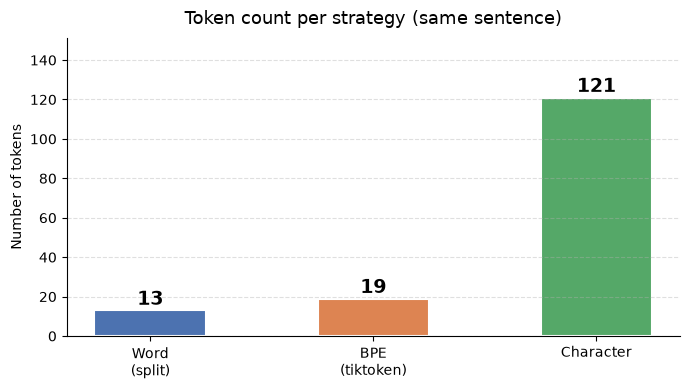


Word  → fewest tokens, but cannot handle unseen words (OOV problem)
BPE   → moderate count, handles any word by splitting into known subwords
Char  → handles everything, but creates very long sequences


In [ ]:
# Bar chart comparison
strategies = ["Word\n(split)", "BPE\n(tiktoken)", "Character"]
counts     = [len(word_tokens), len(bpe_tokens), len(char_tokens)]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(strategies, counts, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha='center', va='bottom', fontsize=14, fontweight='bold'
    )

ax.set_title('Token count per strategy (same sentence)', fontsize=13, pad=10)
ax.set_ylabel('Number of tokens')
ax.set_ylim(0, max(counts) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print()
print("Word  → fewest tokens, but cannot handle unseen words (OOV problem)")
print("BPE   → moderate count, handles any word by splitting into known subwords")
print("Char  → handles everything, but creates very long sequences")

## Summary

| Strategy | How it splits | Pros | Cons |
| --- | --- | --- | --- |
| Word | Whitespace / punctuation | Intuitive, easy | OOV problem — fails on new words |
| Character | One character at a time | No OOV | Very long sequences, slow training |
| **BPE (subword)** | Frequent character pairs merged | No OOV, compact | Less human-readable |

> **Every modern LLM** (GPT, BERT, LLaMA, Gemini) uses a subword tokenizer based on BPE or a similar algorithm.

In [ ]:
# TODO: Mini assignment
#
# Use the paragraph below for all tasks.
#
# 1. Tokenize it using .split() and count the word tokens.
# 2. Tokenize it using tiktoken (enc.encode) and count the BPE tokens.
# 3. Find the single word (from .split()) that gets split into the MOST
#    BPE subword tokens. Print the word and its subword pieces.
#    Hint: loop over the words from .split(), encode each one, find the longest.
# 4. Print the ratio: BPE_tokens / word_tokens  (how many BPE tokens per word on average?)

paragraph = (
    "Transformers use self-attention mechanisms to process sequences in parallel. "
    "Unlike recurrent neural networks, they do not suffer from the vanishing gradient problem. "
    "Tokenization is a preprocessing step that converts raw text into subword representations "
    "so that even unrecognized words like 'ChatGPT' or 'covid19' can be processed without error."
)

# Write your code here:
